## Load packages and define functions

In [1]:
import pandas as pd 
import pyam
import matplotlib.pyplot as plt
import pandas_indexing as pix
from pandas_indexing import isin, ismatch
import numpy as np

import os
from pathlib import Path

from fuzzywuzzy import fuzz

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import data_shepherd as ds
from data_shepherd import utils
import datatoolbox as dt

Config initialised in 0.0014 seconds


In [2]:
def elec(tech=None):
    if not tech is None:
        return f'Secondary Energy|Electricity|{tech}'
    else:
        return 'Secondary Energy|Electricity'

In [3]:
REMIND_RMAP = ds.utils.RegionMapping.from_model('REMIND_2.1')

In [4]:
IKEA_ISOS = ["DEU","POL","BRA","MEX","KEN","MAR","MOZ",
             "NGA","SEN","ZAF","USA","NAM","DZA","TUR","SAU",
             "ARE","BGD","IND","IDN","PAK","VNM","GBR","AUS","CHN","JPN"]

LAM_ISOS = [
    'ABW', 'ARG', 'ATG', 'BHS', 'BLZ', 'BMU', 'BOL', 'BRA', 'BRB', 'CHL', 'COL',
    'CRI', 'CUB', 'CYM', 'DMA', 'DOM', 'ECU', 'FLK', 'GLP', 'GRD', 'GTM', 'GUF',
    'GUY', 'HND', 'HTI', 'JAM', 'KNA', 'LCA', 'MEX', 'MSR', 'MTQ','NIC', 'PAN', 'PER',
    'PRI', 'PRY', 'SLV', 'SUR', 'TCA', 'TTO', 'URY', 'VCT', 'VEN', 'VGB', 'VIR']

IKEA_ISOS.sort()

## Load data

In [5]:
BOX_MOUNT_PATH = Path("~/Library/CloudStorage/Box-Box").expanduser()
if not BOX_MOUNT_PATH.is_dir():
    BOX_MOUNT_PATH = Path("~/Box").expanduser()

In [6]:
DSCALE_PATH = (
    "Climate Policy Team/"
    "02 - Projects/"
    "IKEA NDC 1.5° Pathways 23-25 - phase II/"
    "2 - Work Packages/"
    "WP2 - National 1.5°C Pathways/"
    "Downscaling/"
    "DSCALE"
    
)

DSCALE_PATH: os.PathLike = BOX_MOUNT_PATH / DSCALE_PATH

In [7]:
REMIND_PATH = (
    "Climate Policy Team/"
    "02 - Projects/"
    "IKEA NDC 1.5° Pathways 23-25 - phase II/"
    "2 - Work Packages/"
    "WP1 - Updating global 1.5°C Pathways/"
    "1 - PIK/"
    "Scenario Data/"
    "SUBMITTED_SCENARIOS_August2025/"

)

REMIND_PATH: os.PathLike = BOX_MOUNT_PATH / REMIND_PATH

In [8]:
# INSERT PATHWAY TO INPUT DATA
input_data = pyam.IamDataFrame('../input_data/REMIND_fuel_mix_testing/snapshot_v1/npe_core_scenario_harmonised_AR6_reporting.csv')
input_data_processed = pyam.IamDataFrame('../input_data/REMIND_fuel_mix_testing/multiple_df/snapshot_all_regions_RAW_REMIND-MAgPIE 3.3-4.8.csv')

[INFO] 15:13:55 - pyam.core: Reading file ../input_data/REMIND_fuel_mix_testing/snapshot_v1/npe_core_scenario_harmonised_AR6_reporting.csv
[INFO] 15:13:55 - pyam.core: Reading file ../input_data/REMIND_fuel_mix_testing/multiple_df/snapshot_all_regions_RAW_REMIND-MAgPIE 3.3-4.8.csv


In [9]:
import pandas as pd

# INSERT PATHWAY TO HISTORICAL DATA HERE
df = pd.read_csv(
    DSCALE_PATH / 'data/step1_input_data_for_DSCALE/input_reference_iea_2022.csv'
)

iamc_cols = ["MODEL", "SCENARIO", "REGION", "VARIABLE", "UNIT"]

df_clean = df.drop_duplicates(
    subset=["MODEL", "SCENARIO", "REGION", "VARIABLE", "UNIT"]
)

hist_data_raw = pyam.IamDataFrame(df_clean)

In [ ]:
# # Recalculate parent variables to exclude |Fossil from the total
# # |Fossil has been accounted for in the total sum

hist_data = hist_data_raw.copy()

parent_variables= [
    'Final Energy|Residential and Commercial|Gases',
    'Final Energy|Residential and Commercial|Liquids',
    'Final Energy|Residential and Commercial|Solids', 
    'Final Energy|Transportation|Gases',
    'Final Energy|Transportation|Liquids',
    'Final Energy|Transportation|Solids',
    'Final Energy|Industry|Gases',
    'Final Energy|Industry|Liquids',
    'Final Energy|Industry|Solids',
]

hist_data = hist_data.filter(variable="Final Energy|*|*|Fossil", keep=False)
hist_data = hist_data.filter(variable=parent_variables, keep=False)


hist_data.aggregate(
    'Final Energy|Residential and Commercial|Gases', 
    ['Final Energy|Residential and Commercial|Gases|Biomass',
    'Final Energy|Residential and Commercial|Gases|Electricity',
    'Final Energy|Residential and Commercial|Gases|Natural gas',
], append=True
)

hist_data.aggregate(
    'Final Energy|Residential and Commercial|Liquids', 
    ['Final Energy|Residential and Commercial|Liquids|Biomass',
    'Final Energy|Residential and Commercial|Liquids|Electricity',
    'Final Energy|Residential and Commercial|Liquids|Oil and Other',
], append=True
)

hist_data.aggregate(
    'Final Energy|Residential and Commercial|Solids', 
    ['Final Energy|Residential and Commercial|Solids|Biomass',
    'Final Energy|Residential and Commercial|Solids|Coal',
], append=True
)

hist_data.aggregate(
    'Final Energy|Industry|Gases', 
    ['Final Energy|Industry|Gases|Biomass',
    'Final Energy|Industry|Gases|Electricity',
    'Final Energy|Industry|Gases|Natural gas',
], append=True
)

hist_data.aggregate(
    'Final Energy|Industry|Liquids', 
    ['Final Energy|Industry|Liquids|Biomass',
    'Final Energy|Industry|Liquids|Electricity',
    'Final Energy|Industry|Liquids|Oil and Other',
], append=True
)

hist_data.aggregate(
    'Final Energy|Industry|Solids', 
    ['Final Energy|Industry|Solids|Biomass',
    'Final Energy|Industry|Solids|Coal',
], append=True
)

hist_data.aggregate(
    'Final Energy|Transportation|Gases', 
    ['Final Energy|Transportation|Gases|Biomass',
    'Final Energy|Transportation|Gases|Electricity',
    'Final Energy|Transportation|Gases|Natural gas',
], append=True
)

hist_data.aggregate(
    'Final Energy|Transportation|Liquids', 
    ['Final Energy|Transportation|Liquids|Biomass',
    'Final Energy|Transportation|Liquids|Electricity',
    'Final Energy|Transportation|Liquids|Oil and Other',
], append=True
)

hist_data.aggregate(
    'Final Energy|Transportation|Solids', 
    ['Final Energy|Transportation|Solids|Biomass',
    'Final Energy|Transportation|Solids|Coal',
], append=True
)


for sector in ['Transportation','Industry','Residential and Commercial']:
    hist_data.filter(variable=[f'Final Energy|{sector}'],keep=False,inplace=True)
    hist_data.aggregate(
        f'Final Energy|{sector}',
        [
            f'Final Energy|{sector}|Liquids',
            f'Final Energy|{sector}|Solids',
            f'Final Energy|{sector}|Gases',
        ],
        append=True
    )




In [ ]:
# PUT PATH TO YOUR DSCALE RESULTS IN HERE

# dscale_results = pyam.IamDataFrame(DSCALE_PATH /  'outputs/results_harmo_AR6_template/REMIND-MAgPIE 3.3-4.8_REMIND_2025_AR6_Template_2026_01_20_harmonised_2022_harmo_step5e_None.csv')

# dscale_results = pyam.IamDataFrame('../results/5_Explorer_and_New_Variables/REMIND-MAgPIE 3.3-4.8_REMIND_2025_for_testing_fuel_mix_testing_30012026_2022_harmo_step5e_None.csv')

dscale_results = pyam.IamDataFrame('../results/5_Explorer_and_New_Variables/REMIND-MAgPIE 3.3-4.8_REMIND_fuel_mix_testing_fuel_mix_testing_30012026_2022_harmo_step5e_None.csv')

[INFO] 15:13:58 - pyam.core: Reading file ../results/5_Explorer_and_New_Variables/REMIND-MAgPIE 3.3-4.8_REMIND_fuel_mix_testing_fuel_mix_testing_30012026_2022_harmo_step5e_None.csv


In [ ]:

# Regroup all the rescaled countries within their regions

region_map = {
    'R10AFRICA':'SSA',
    'R10CHINA+':'CHA',
    'R10EUROPE':'EUR',
    'R10LATIN_AM':'LAM',
    'R10MIDDLE_EAST':'MEA',
    'R10REF_ECON':'REF',
    'R10REST_ASIA':'OAS',
    'R10NORTH_AM':'USA',
    'R10PAC_OECD':'JPN',
    'R10INDIA+':'IND',
    'R10ROWO':'ROWO',
    'World':'World'}


def create_macro_df(idf: pyam.IamDataFrame):
    """Converts data at country level to macro-region data"""

    # Dataset preparation
    df_country = idf.timeseries()
    df_country.index.names = ['model', 'scenario', 'country', 'variable', 'unit']
    
    # Label each country based on what region it's part of
    df_country = df_country.pix.semijoin(REMIND_RMAP.index, how="left")

    # Kick out countries which don't have a region mapping               
    df_country=df_country.loc[~isin(region=np.nan)]
    
    # # Groupby regions and sum (much faster than doing in pyam)
    df_country = pyam.IamDataFrame(
        df_country
        .groupby(['model','scenario','variable','unit','region'])
        .sum())
    
    df_region = pyam.IamDataFrame(df_country)
       
    # Drop 2023 data as it is currently missing quite a few countries (and so the regional totals are off)
    df_region.filter(year=2023,keep=False,inplace=True)

    # Rename regions
    df_region = (df_region
                 .rename(region=region_map)
                 .filter(region=['SSA','CHA','NEU','CAZ','EUR','IND','LAM','MEA','USA','JPN','REF','OAS'])
                )

    # Add world data
    for var in df_region.variable:
        df_region.aggregate_region(
            var,
            'World',
            append=True)

    return pyam.IamDataFrame(df_region.timeseries())

In [ ]:
dscale_results_agg = create_macro_df(dscale_results)

In [60]:
hist_agg = create_macro_df(hist_data)
hist_agg.filter(year=[2023,2024],keep=False,inplace=True) 
#Drop 2023/2024 data as underlying country data is regionally incomplete and so you get aggregation errors

# PLOTTING DATA

In [15]:
from typing import Union, List, Iterable

def final_energy(
    sector: Union[str, Iterable[str], None] = None,
    fuel: Union[str, Iterable[str], None] = None
) -> Union[str, List[str]]:
    """
    Build Final Energy IAM variable strings.

    Supports single or multiple sectors and/or fuels.

    Parameters
    ----------
    sector : str or list[str], optional
        Sector(s), e.g. 'Industry', ['Industry', 'Transportation']
    fuel : str or list[str], optional
        Fuel(s), e.g. 'Liquids', ['Liquids', 'Gases', '*']

    Returns
    -------
    str or list[str]
        IAM variable string(s)
    """

    base = "Final Energy"

    # Normalize to lists
    sectors = [sector] if isinstance(sector, str) else sector
    fuels = [fuel] if isinstance(fuel, str) else fuel

    # Case 1: no sector, no fuel
    if sectors is None and fuels is None:
        return f"{base}|"

    results = []

    # Case 2: fuel only
    if sectors is None:
        for f in fuels:
            results.append(f"{base}|{f}")

    # Case 3: sector only
    elif fuels is None:
        for s in sectors:
            results.append(f"{base}|{s}")

    # Case 4: sector + fuel (cartesian product)
    else:
        for s in sectors:
            for f in fuels:
                results.append(f"{base}|{s}|{f}")

    return results[0] if len(results) == 1 else results

## Exploring

In [176]:
# First, look at regional consistency – do the DSCALE results add back up to the regional level?

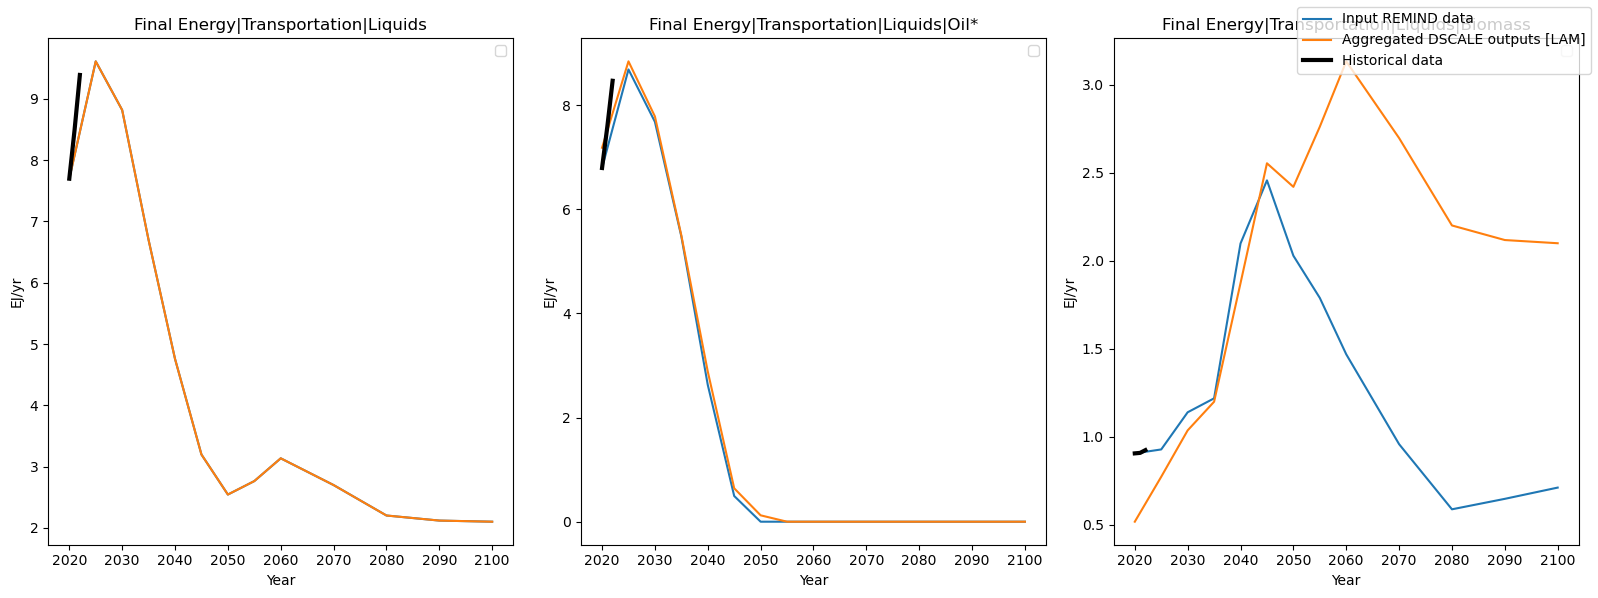

In [61]:
fuels = ['','|Oil*','|Biomass']
phase = 'Liquids'
sector = 'Transportation'


f, axes = plt.subplots(ncols=3,figsize=(16,6))

for count, ax in enumerate(axes.ravel()):

    # input_data.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='*LAM',scenario='NPE-core',year=range(2010,2101)).plot(ax=ax)
    input_data_processed.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='*LAM',scenario='NPE-core',year=range(2020,2101)).plot(ax=ax)
    dscale_results_agg.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='LAM',year=range(2020,2101)).plot(ax=ax)
    hist_agg.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='LAM',year=range(2020,2101)).plot(ax=ax,color='k',lw=3)
    ax.set_title(f'Final Energy|{sector}|{phase}{fuels[count]}')

f.legend(['Input REMIND data','Aggregated DSCALE outputs [LAM]','Historical data'])
plt.tight_layout()

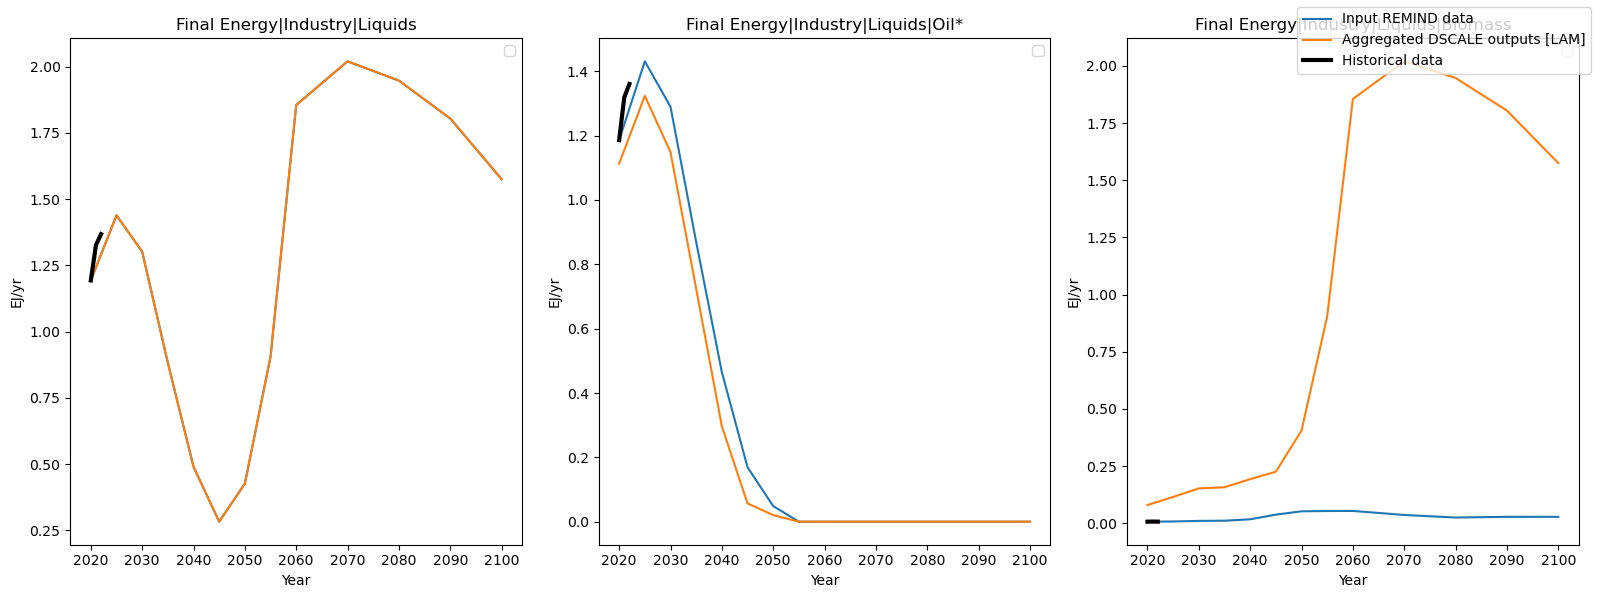

In [20]:
fuels = ['','|Oil*','|Biomass']
phase = 'Liquids'
sector = 'Industry'


f, axes = plt.subplots(ncols=3,figsize=(16,6))

for count, ax in enumerate(axes.ravel()):

    # input_data.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='*LAM',scenario='NPE-core',year=range(2010,2101)).plot(ax=ax)
    input_data_processed.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='*LAM',scenario='NPE-core',year=range(2020,2101)).plot(ax=ax)
    dscale_results_agg.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='LAM',year=range(2020,2101)).plot(ax=ax)
    hist_agg.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='LAM',year=range(2020,2101)).plot(ax=ax,color='k',lw=3)
    ax.set_title(f'Final Energy|{sector}|{phase}{fuels[count]}')

f.legend(['Input REMIND data','Aggregated DSCALE outputs [LAM]','Historical data'])
plt.tight_layout()

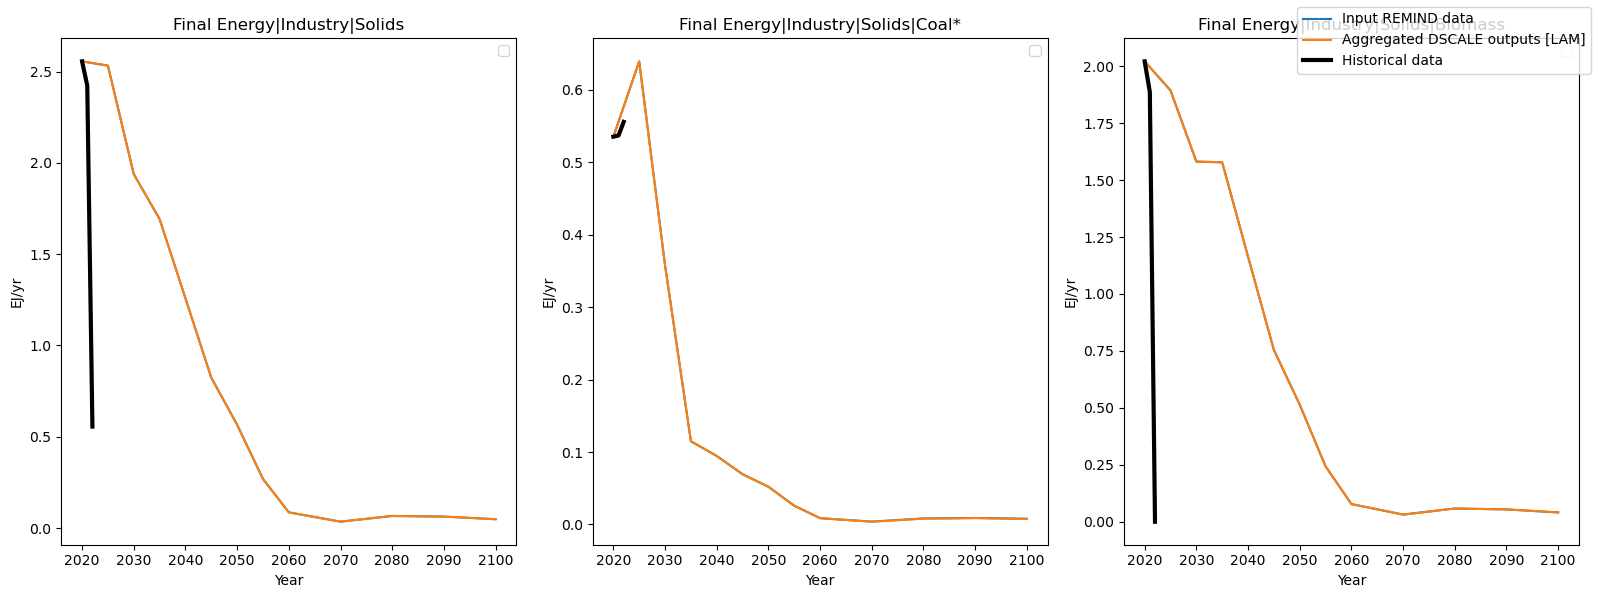

In [24]:
fuels = ['','|Coal*','|Biomass']
phase = 'Solids'
sector = 'Industry'


f, axes = plt.subplots(ncols=3,figsize=(16,6))

for count, ax in enumerate(axes.ravel()):

    # input_data.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='*LAM',scenario='NPE-core',year=range(2010,2101)).plot(ax=ax)
    input_data_processed.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='*LAM',scenario='NPE-core',year=range(2020,2101)).plot(ax=ax)
    dscale_results_agg.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='LAM',year=range(2020,2101)).plot(ax=ax)
    hist_agg.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='LAM',year=range(2020,2101)).plot(ax=ax,color='k',lw=3)
    ax.set_title(f'Final Energy|{sector}|{phase}{fuels[count]}')

f.legend(['Input REMIND data','Aggregated DSCALE outputs [LAM]','Historical data'])
plt.tight_layout()

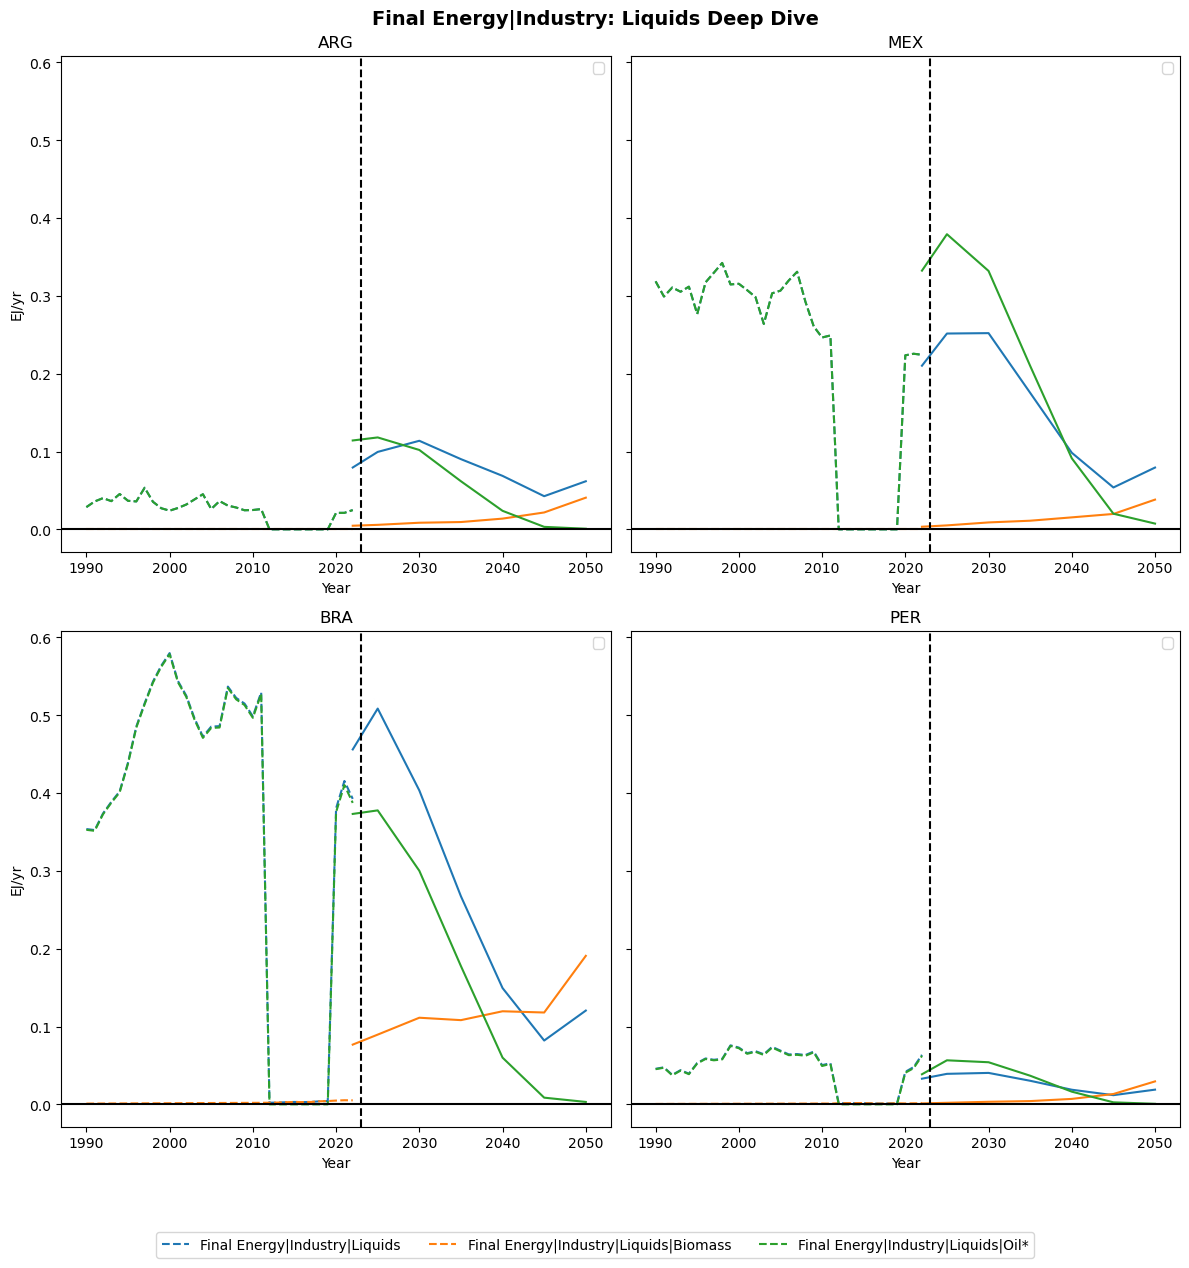

In [31]:
f, axes = plt.subplots(nrows=2,ncols=2,figsize=(12,12),sharey=True)

#plot_vars = final_energy("Residential and Commercial", ["Liquids", "Electricity", "Solids"])
plot_vars = final_energy("Industry", ["Liquids","Liquids|Biomass","Liquids|Oil*"])#, "Electricity", "Gases", "Solids"])
plot_isos = ['ARG','MEX','BRA','PER']

interpolated_data = dscale_results.filter(variable=plot_vars).interpolate(time=range(2010,2101,1))


for count, ax in enumerate(axes.ravel()[:len(plot_isos)]):
    hist_data.filter(variable=plot_vars, region=plot_isos[count], year=range(1990,2023)).plot(ax=ax, linestyle="--", color="variable")
    interpolated_data.filter(variable=plot_vars, region=plot_isos[count], year=range(2022,2051)).plot(ax=ax, color="variable")
    
    ax.axvline(x=2023,color='k',ls='--')
    ax.axhline(y=0,color='k',ls='-')
    ax.set_title(plot_isos[count])
    ax.legend([])


f.suptitle('Final Energy|Industry: Liquids Deep Dive',fontsize=14,fontweight='bold')
f.legend(plot_vars,ncols=4,loc='center',bbox_to_anchor=[0.5,-0.05])
plt.tight_layout()

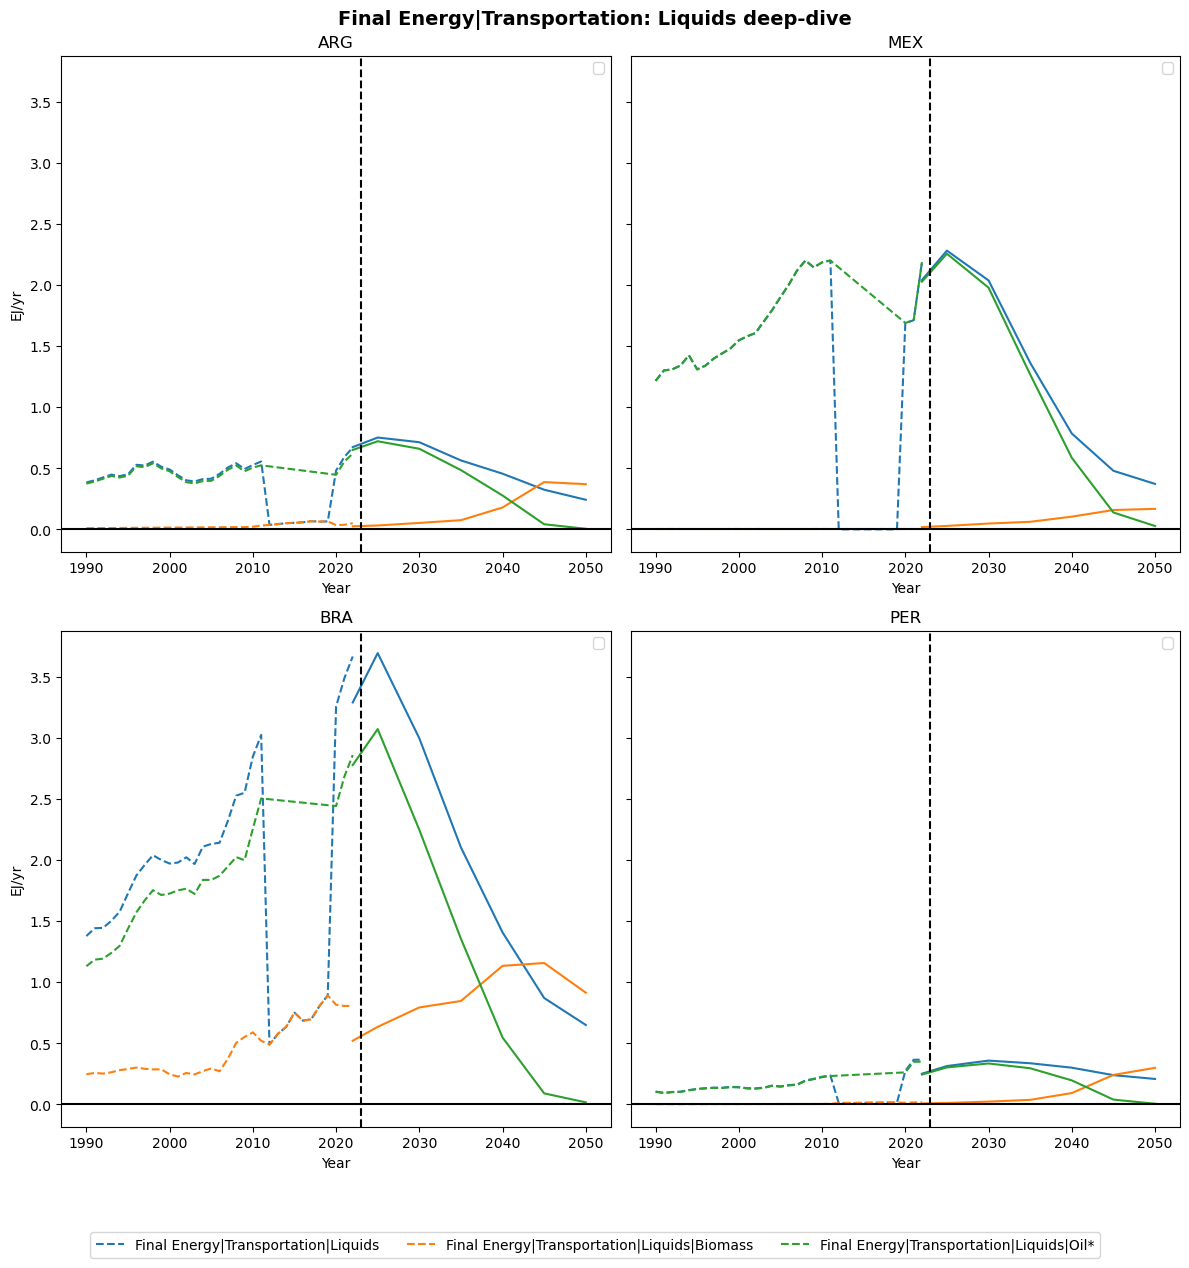

In [30]:
f, axes = plt.subplots(nrows=2,ncols=2,figsize=(12,12),sharey=True)

#plot_vars = final_energy("Residential and Commercial", ["Liquids", "Electricity", "Solids"])
plot_vars = final_energy("Transportation", ["Liquids","Liquids|Biomass","Liquids|Oil*"])#, "Electricity", "Gases", "Solids"])
plot_isos = ['ARG','MEX','BRA','PER']

interpolated_data = dscale_results.filter(variable=plot_vars).interpolate(time=range(2010,2101,1))


for count, ax in enumerate(axes.ravel()[:len(plot_isos)]):
    hist_data.filter(variable=plot_vars, region=plot_isos[count], year=range(1990,2023)).plot(ax=ax, linestyle="--", color="variable")
    interpolated_data.filter(variable=plot_vars, region=plot_isos[count], year=range(2022,2051)).plot(ax=ax, color="variable")
    
    ax.axvline(x=2023,color='k',ls='--')
    ax.axhline(y=0,color='k',ls='-')
    ax.set_title(plot_isos[count])
    ax.legend([])


f.suptitle('Final Energy|Transportation: Liquids deep-dive',fontsize=14,fontweight='bold')
f.legend(plot_vars,ncols=4,loc='center',bbox_to_anchor=[0.5,-0.05])
plt.tight_layout()

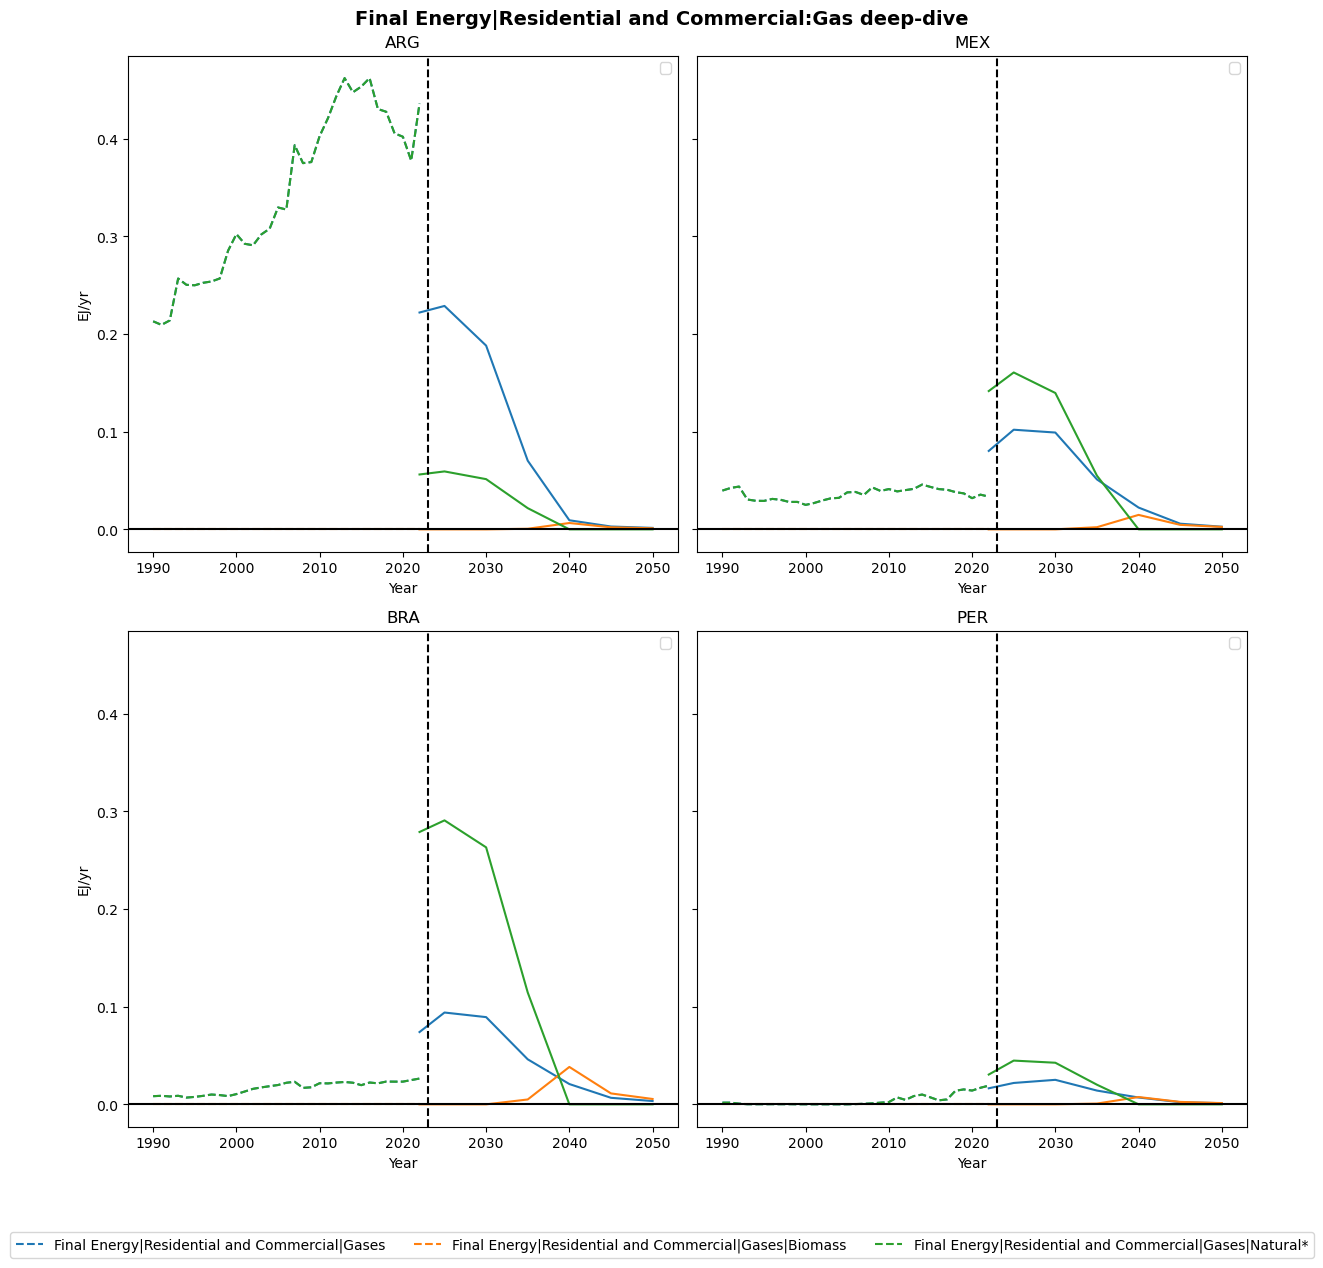

In [32]:
f, axes = plt.subplots(nrows=2,ncols=2,figsize=(12,12),sharey=True)

#plot_vars = final_energy("Residential and Commercial", ["Liquids", "Electricity", "Solids"])
plot_vars = final_energy("Residential and Commercial", ["Gases","Gases|Biomass","Gases|Natural*"])#, "Electricity", "Gases", "Solids"])
plot_isos = ['ARG','MEX','BRA','PER']

interpolated_data = dscale_results.filter(variable=plot_vars).interpolate(time=range(2010,2101,1))


for count, ax in enumerate(axes.ravel()[:len(plot_isos)]):
    hist_data.filter(variable=plot_vars, region=plot_isos[count], year=range(1990,2023)).plot(ax=ax, linestyle="--", color="variable")
    interpolated_data.filter(variable=plot_vars, region=plot_isos[count], year=range(2022,2051)).plot(ax=ax, color="variable")
    
    ax.axvline(x=2023,color='k',ls='--')
    ax.axhline(y=0,color='k',ls='-')
    ax.set_title(plot_isos[count])
    ax.legend([])


f.suptitle('Final Energy|Residential and Commercial:Gas deep-dive',fontsize=14,fontweight='bold')
f.legend(plot_vars,ncols=4,loc='center',bbox_to_anchor=[0.5,-0.05])
plt.tight_layout()

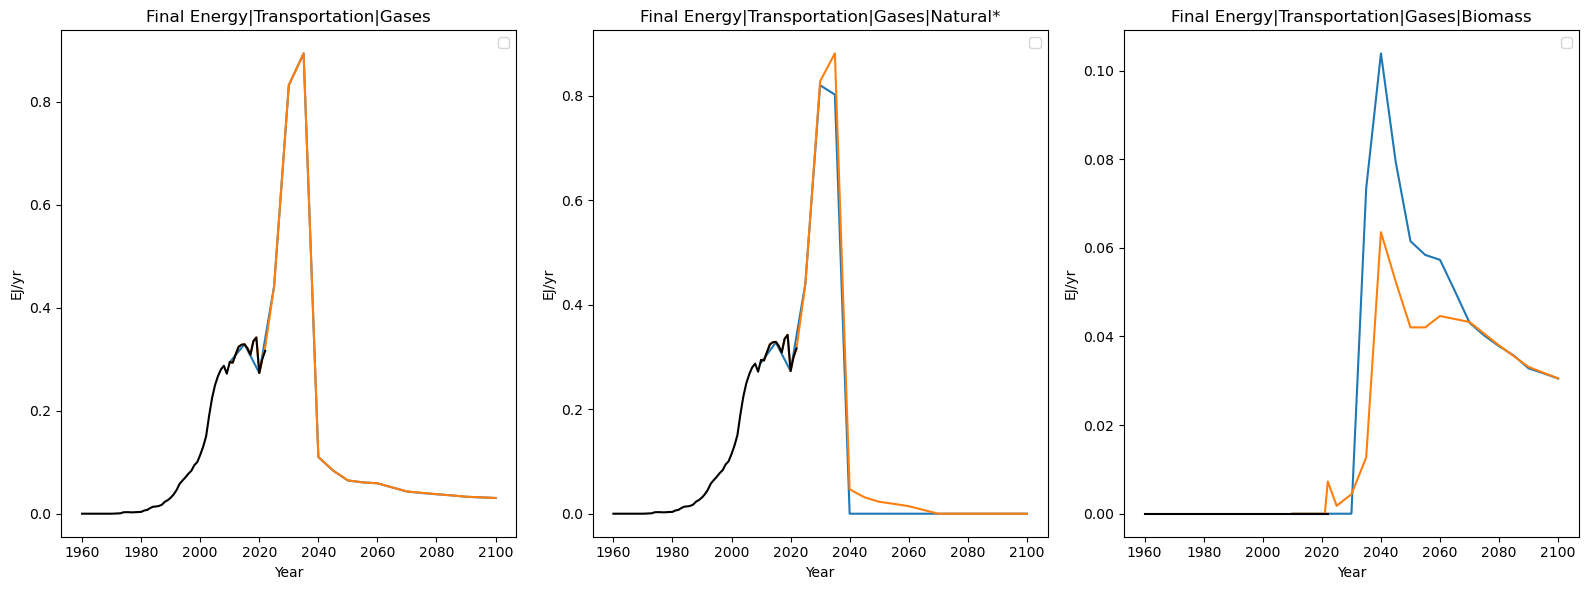

In [33]:
fuels = ['','|Natural*','|Biomass']
phase = 'Gases'
sector = 'Transportation'


f, axes = plt.subplots(ncols=3,figsize=(16,6))

for count, ax in enumerate(axes.ravel()):

    dscale_results_agg.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='LAM').plot(ax=ax)
    input_data.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='LAM').plot(ax=ax)
    hist_agg.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='LAM').plot(ax=ax,color='k')
    ax.set_title(f'Final Energy|{sector}|{phase}{fuels[count]}')

plt.tight_layout()

## Power and primary energy

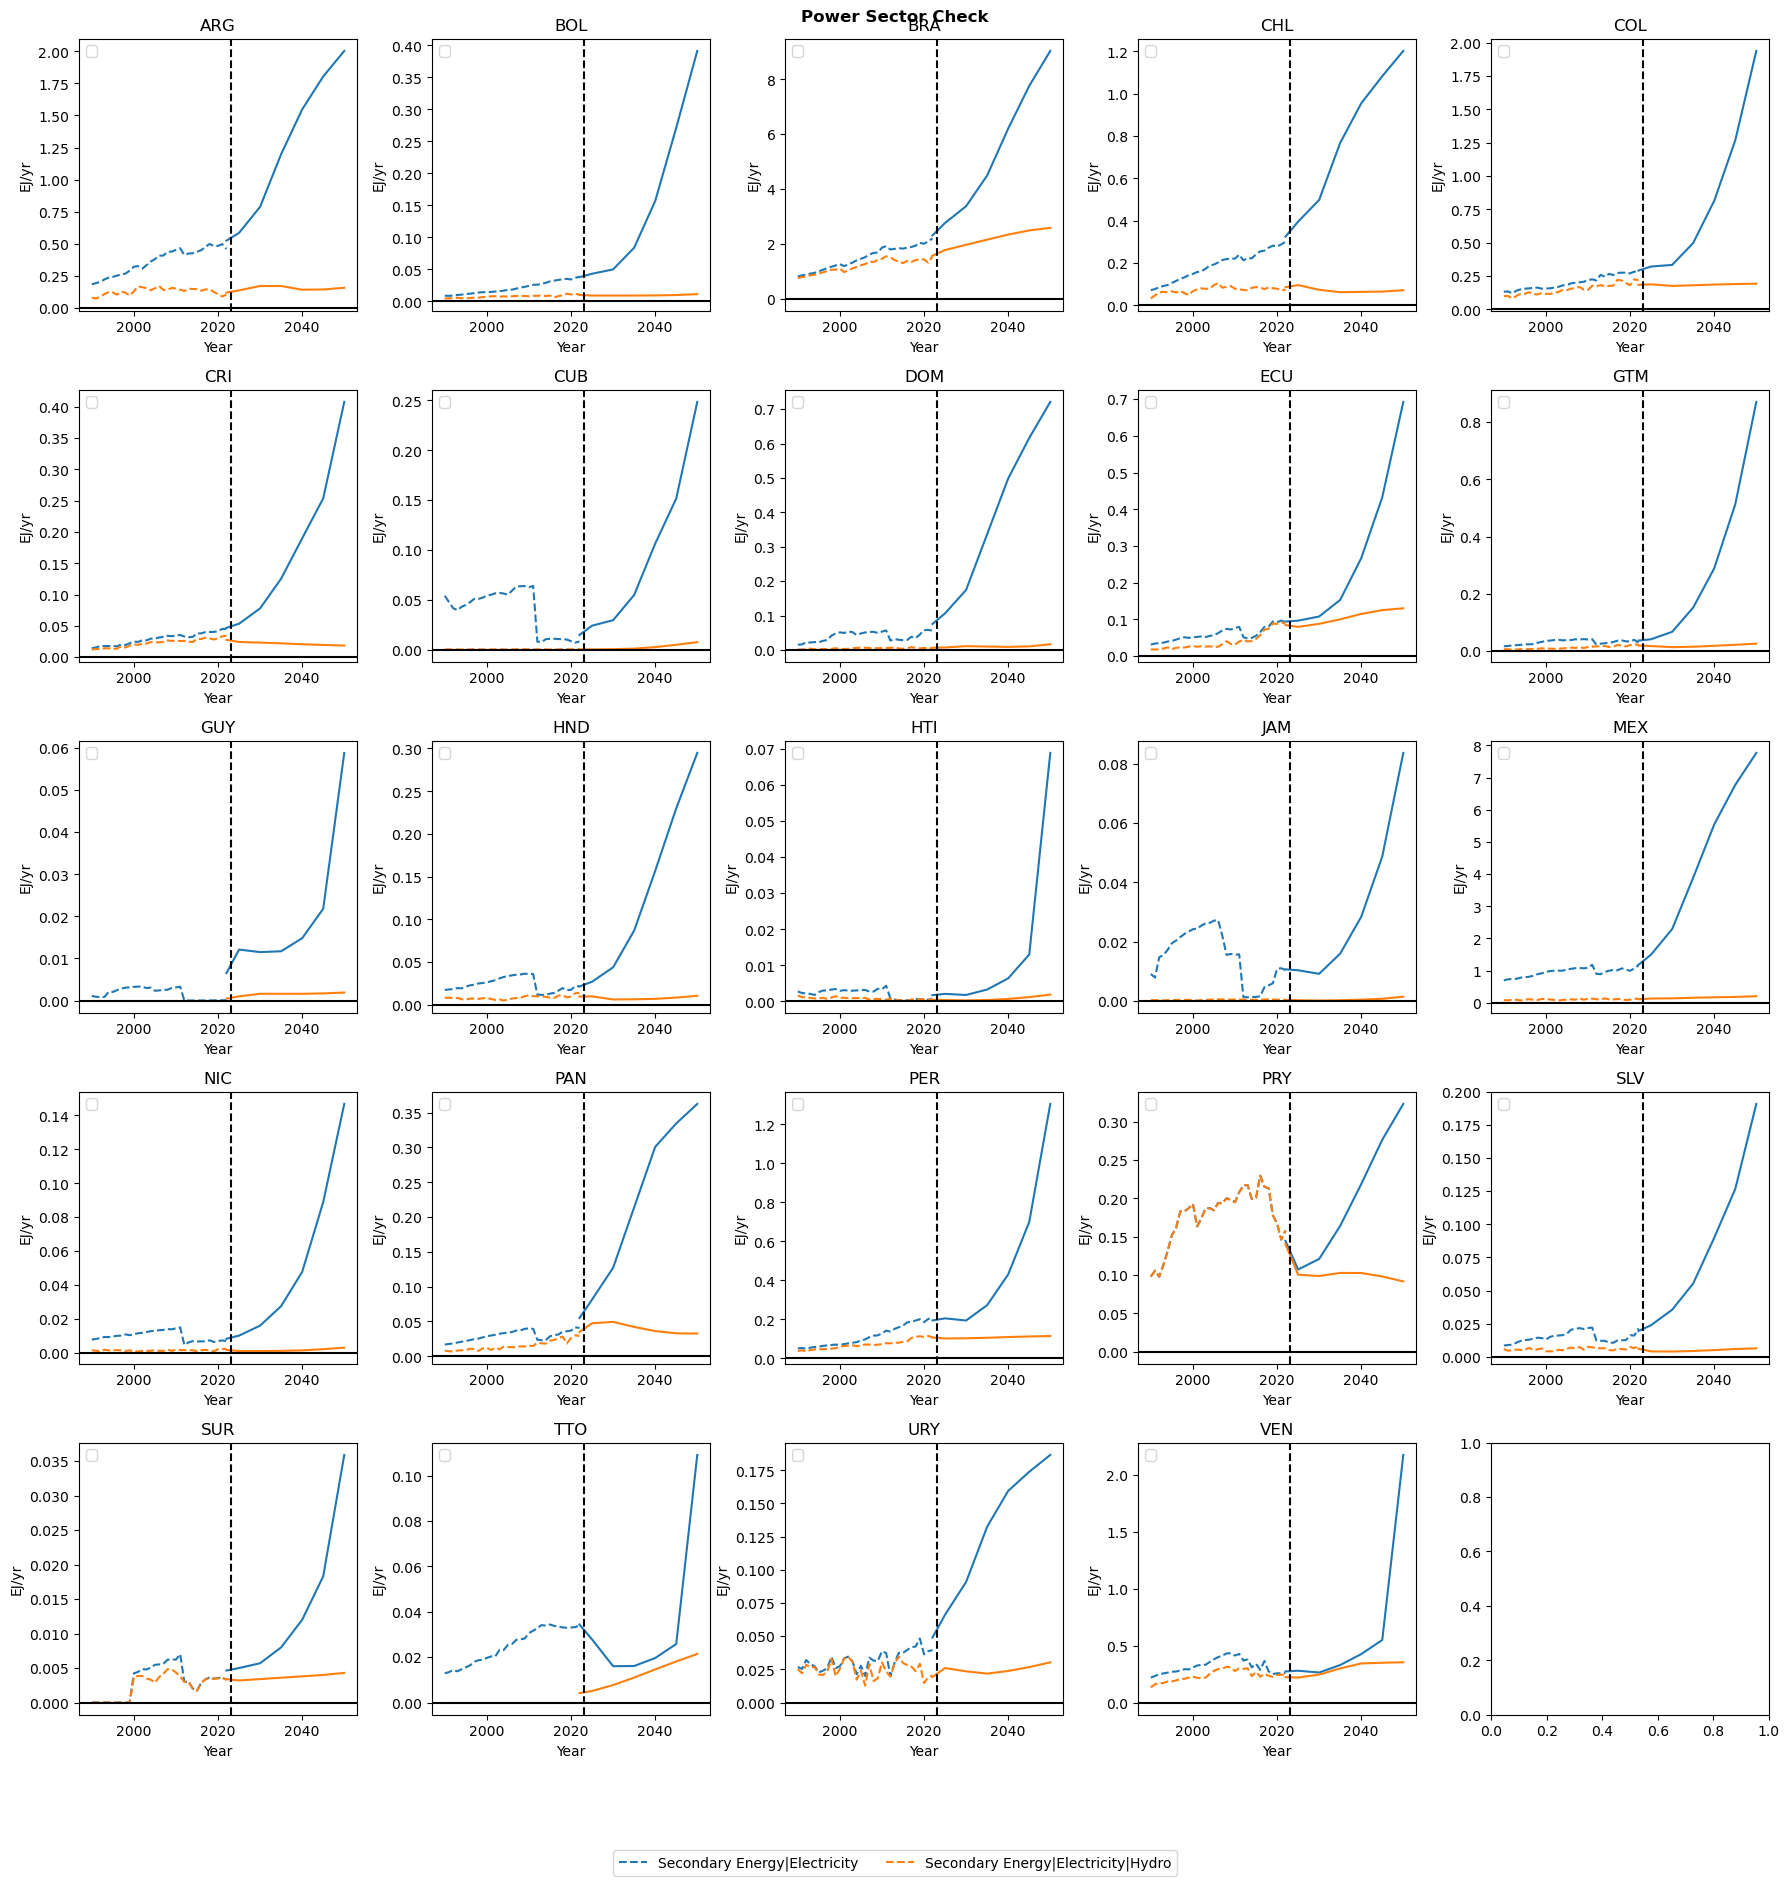

In [37]:
f, axes = plt.subplots(nrows=5,ncols=5,figsize=(18,18))
#plot_vars = final_energy("Residential and Commercial", ["Liquids", "Electricity", "Solids"])
plot_vars = ["Secondary Energy|Electricity",'Secondary Energy|Electricity|Hydro']
plot_isos = hist_data.filter(region=LAM_ISOS).region


interpolated_data = dscale_results.filter(variable=plot_vars).interpolate(time=range(2010,2101,1))


for count, ax in enumerate(axes.ravel()[:len(plot_isos)]):
    hist_data.filter(variable=plot_vars, region=plot_isos[count], year=range(1990,2023)).plot(ax=ax, linestyle="--", color="variable")
    interpolated_data.filter(variable=plot_vars, region=plot_isos[count], year=range(2022,2051)).plot(ax=ax, color="variable")
    
    ax.axvline(x=2023,color='k',ls='--')
    ax.axhline(y=0,color='k',ls='-')
    ax.set_title(plot_isos[count])
    ax.legend([])

f.suptitle('Power Sector Check',fontweight='bold')

f.legend(plot_vars,ncols=4,loc='center',bbox_to_anchor=[0.5,-0.05])
plt.tight_layout()

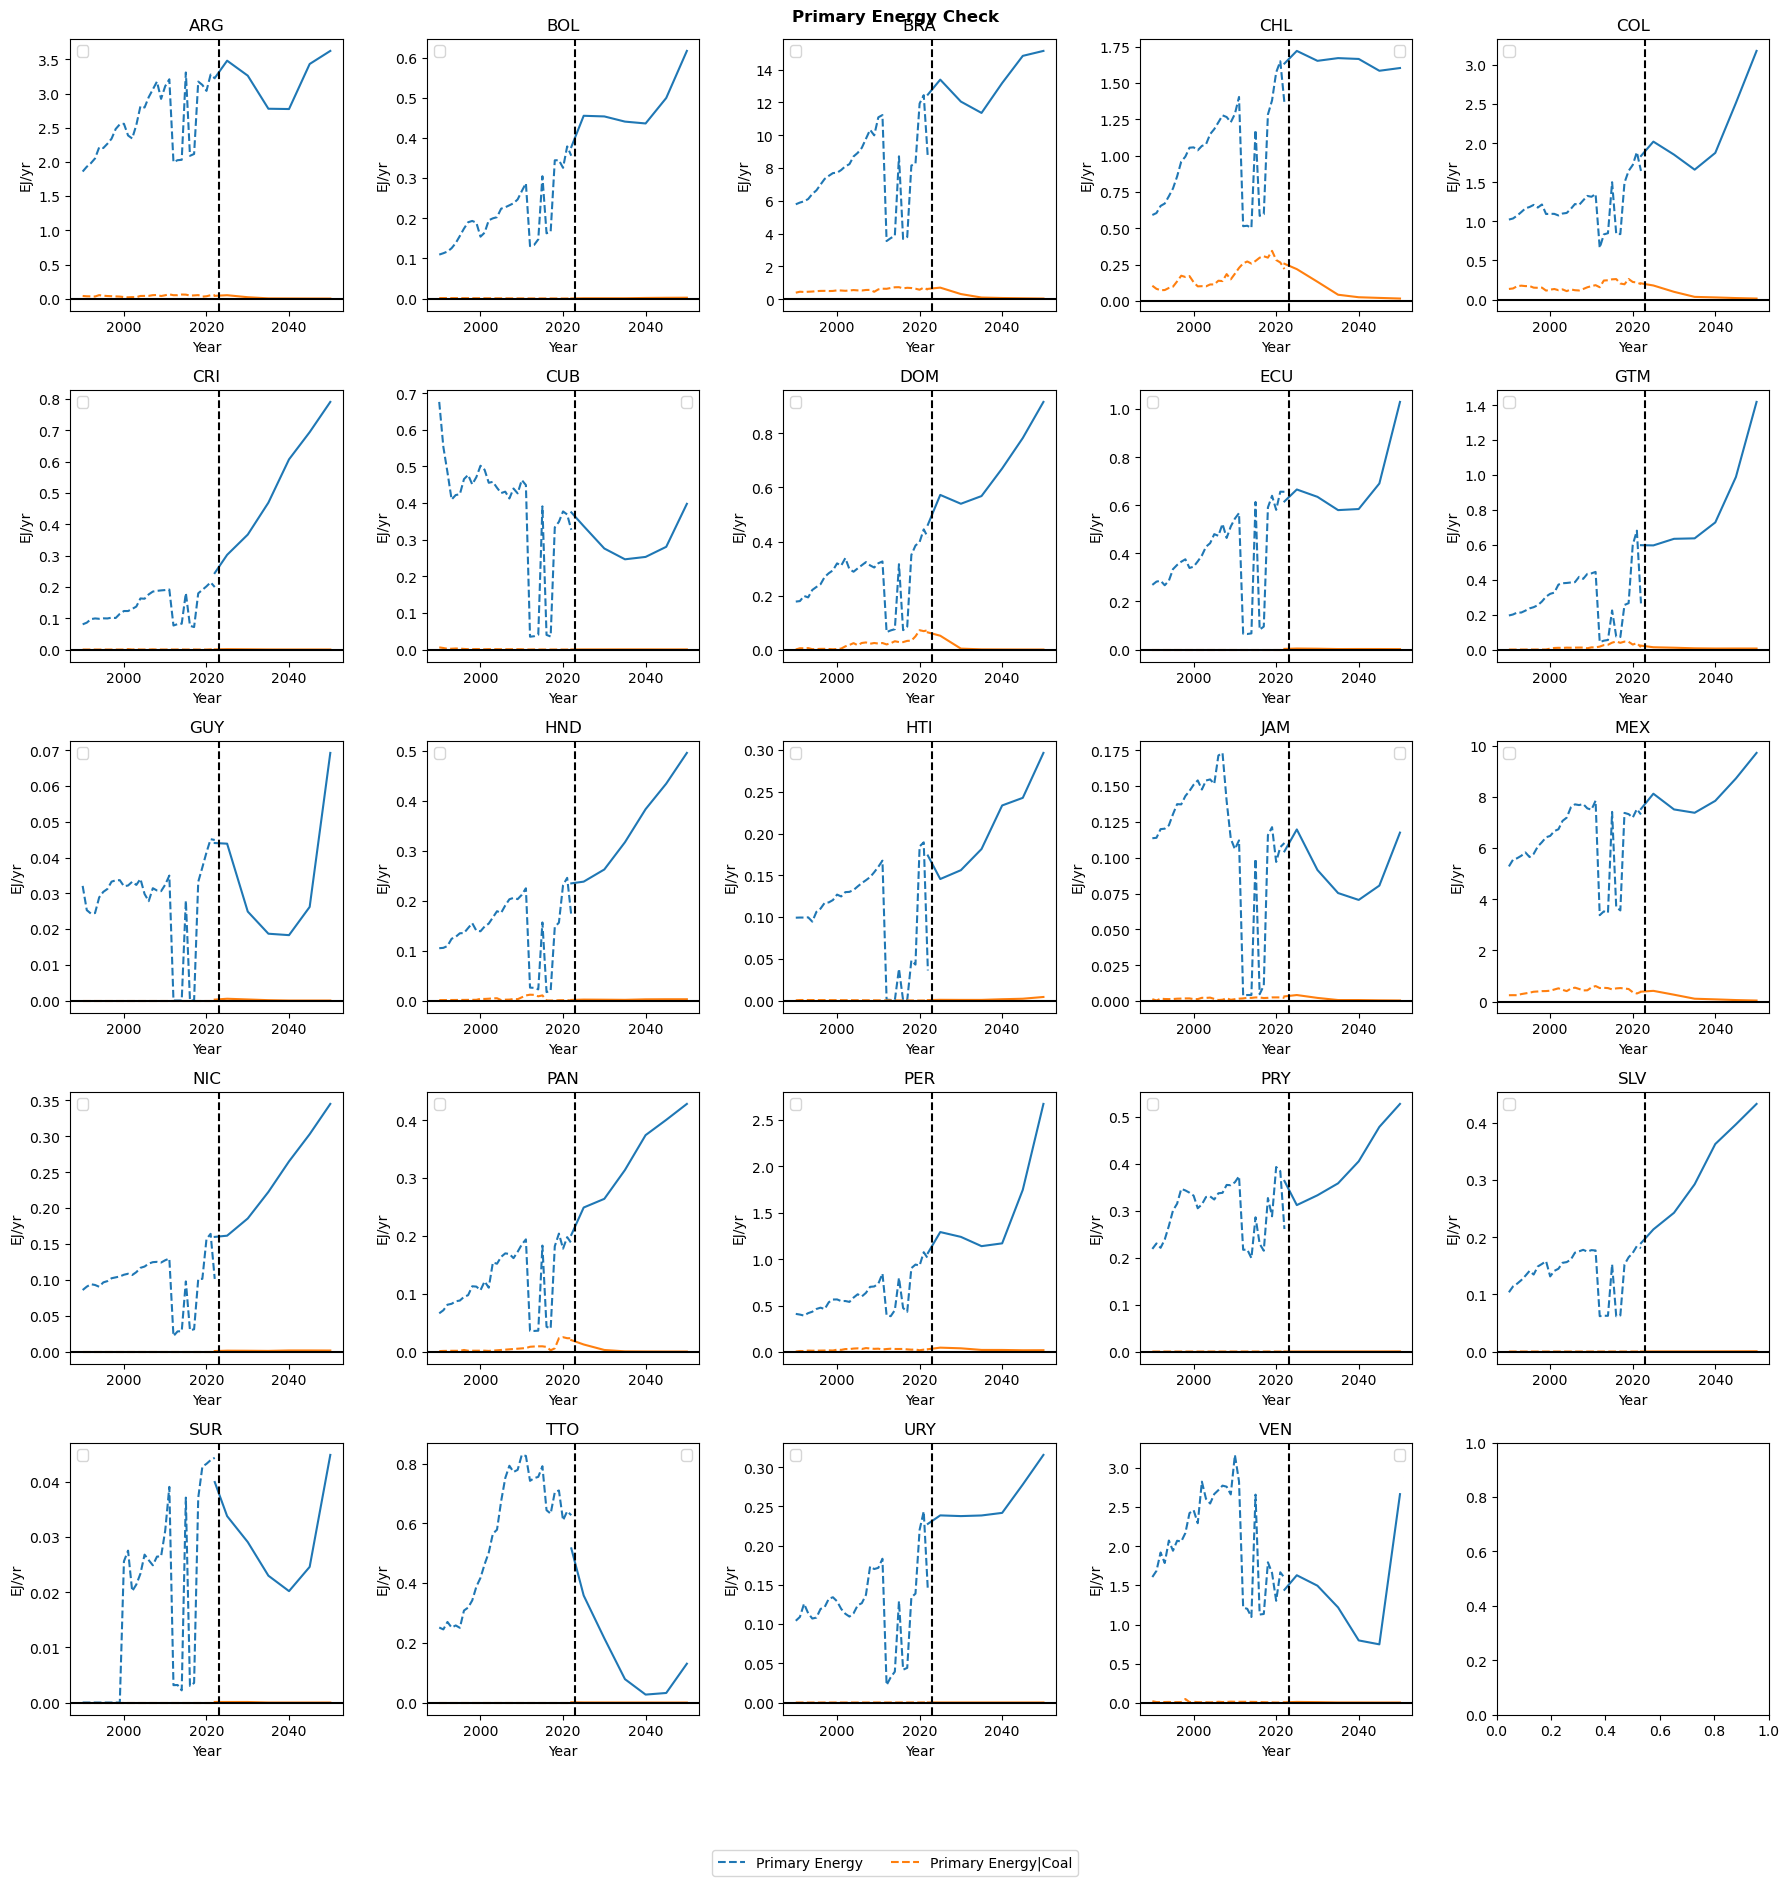

In [ ]:
f, axes = plt.subplots(nrows=5,ncols=5,figsize=(18,18))
#plot_vars = final_energy("Residential and Commercial", ["Liquids", "Electricity", "Solids"])
plot_vars = ["Primary Energy",'Primary Energy|Coal'
'']
plot_isos = hist_data.filter(region=LAM_ISOS).region


interpolated_data = dscale_results.filter(variable=plot_vars).interpolate(time=range(2010,2101,1))


for count, ax in enumerate(axes.ravel()[:len(plot_isos)]):
    hist_data.filter(variable=plot_vars, region=plot_isos[count], year=range(1990,2023)).plot(ax=ax, linestyle="--", color="variable")
    interpolated_data.filter(variable=plot_vars, region=plot_isos[count], year=range(2022,2051)).plot(ax=ax, color="variable")
    
    ax.axvline(x=2023,color='k',ls='--')
    ax.axhline(y=0,color='k',ls='-')
    ax.set_title(plot_isos[count])
    ax.legend([])

f.suptitle('Primary Energy Check',fontweight='bold')

f.legend(plot_vars,ncols=4,loc='center',bbox_to_anchor=[0.5,-0.05])
plt.tight_layout()

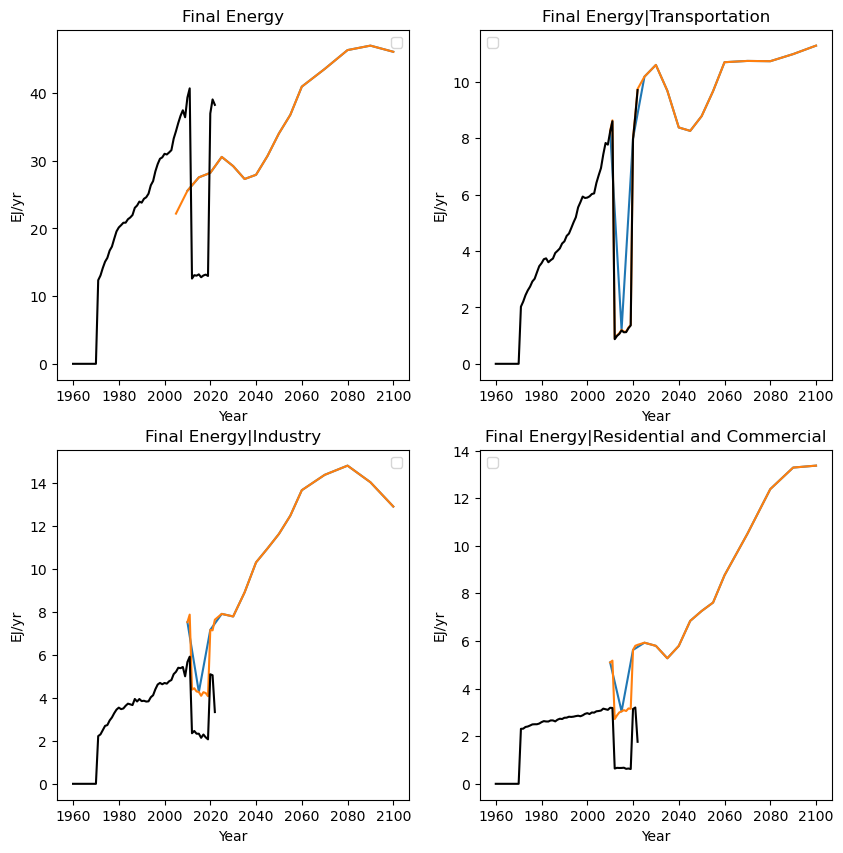

In [62]:
f, ax = plt.subplots(nrows=2,ncols=2,figsize=(10,10))

sectors = ['Final Energy','Final Energy|Transportation','Final Energy|Industry','Final Energy|Residential and Commercial']

for count, ax in enumerate(ax.ravel()):
    plt.sca(ax)
    dscale_results_agg.filter(variable=sectors[count],region='LAM').plot(ax=plt.gca())
    input_data.filter(variable=sectors[count],region='LAM').plot(ax=plt.gca())
    hist_agg.filter(variable=sectors[count],region='LAM').plot(ax=plt.gca(),color='k')
    ax.set_title(f'{sectors[count]}')

<Axes: title={'center': 'model: IEA - scenario: Historic data - region: LAM - variable: Secondary Energy|Electricity'}, xlabel='Year', ylabel='EJ/yr'>

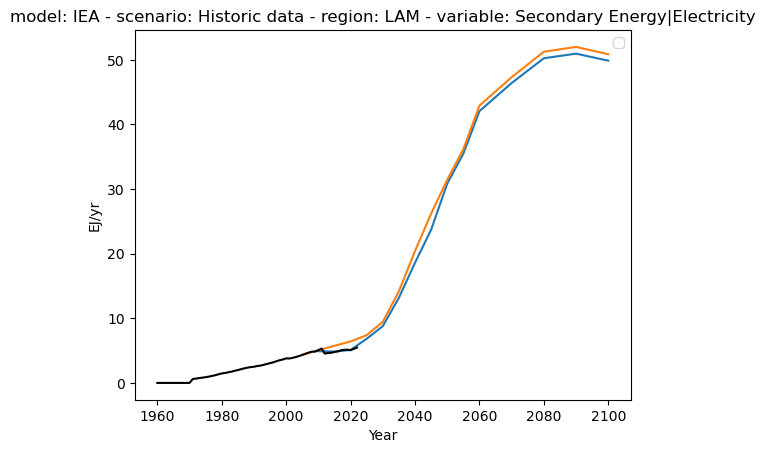

In [ ]:
dscale_results_agg.filter(variable='Secondary Energy|Electricity',region='LAM').plot()
input_data.filter(variable='Secondary Energy|Electricity',region='LAM').plot(ax=plt.gca())
hist_agg.filter(variable='Secondary Energy|Electricity',region='LAM').plot(ax=plt.gca(),color='k')
# ax.set_title(f'Final Energy|{sector}|{phase}{fuels[count]}')